# Multi-Model AutoML LOOCV Pipeline — FC edge (CUD vs HC 판별 엣지 2개)

`automl_comparison_paired_FC_ROI_edge.ipynb`와 **동일한 파이프라인**이다. 뇌 피처만 교체했다.

- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + FC edge **8개** (Residualized)
- **제거 변수**: age, sex, **mean_fd**  /  **타겟**: vas_t1  /  **n = 44**

## 엣지 선정 근거

선행연구가 **CUD vs HC 를 판별**한다고 보고한 엣지 2개. 좌표(MNI) 계산이 필요 없었다 —
논문이 해부학적 이름으로 써놨으므로 DK 영역명에 직접 대응시켰다.

| 논문 라벨 | DK 영역 |
|---|---|
| cuneus | `cuneus` |
| precuneus | `precuneus` |
| middle cingulate | `posteriorcingulate` |
| superior temporal | `superiortemporal` |

**엣지 2개**: `cuneus ↔ precuneus`,  `middle cingulate ↔ superior temporal`

## 반구 처리 — 4조합 전부 개별 피처

DK는 좌/우를 분리하므로 각 엣지에 반구조합 4개(lh-lh, lh-rh, rh-lh, rh-rh)가 있다.
**4조합을 모두 개별 피처로** 사용한다 → 엣지 2개 × 4 = **8개**.

| 엣지 | 컬럼 |
|---|---|
| cuneus–precuneus | `lh_cuneus__lh_precuneus`, `lh_cuneus__rh_precuneus`, `lh_precuneus__rh_cuneus`, `rh_cuneus__rh_precuneus` |
| midCingulate–STG | `lh_posteriorcingulate__lh_superiortemporal`, `lh_posteriorcingulate__rh_superiortemporal`, `lh_superiortemporal__rh_posteriorcingulate`, `rh_posteriorcingulate__rh_superiortemporal` |

(컬럼명은 `{regionA}__{regionB}`, 양끝 순서는 lh피질 → rh피질 순서로 고정되어 있어
반구를 바꾸면 앞뒤가 뒤집힌다.)

## 주의

- 피처 8개 / n=44 → p/n ≈ 0.18. 다른 FC edge 노트북(4피처)보다 파라미터가 많다.
- `middle cingulate` 는 DK에 정확한 대응이 없어 `posteriorcingulate` 로 근사했다
  (중대상회는 DK에서 대개 posterior/caudal cingulate 로 흡수됨).
- 논문 마스크 전체는 미공개 → "논문 재현"이 아니라 **"논문이 보고한 영역을 우리 아틀라스에서 근사한 탐색적 분석"**.

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (FC edges — CUD vs HC 판별 엣지 2개)
# ==========================================================
df = pd.read_csv('fc_full_84x84_edited.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()

# 논문(CUD vs HC 판별) 보고 엣지 2개를 DK 이름으로 대응:
#   cuneus ↔ precuneus
#   middle cingulate(=posteriorcingulate) ↔ superior temporal(=superiortemporal)
# 반구조합 4개(lh-lh, lh-rh, rh-lh, rh-rh)를 전부 개별 피처로 사용 → 2 × 4 = 8개.
brain_features = [
    # 엣지 1: cuneus – precuneus
    'lh_cuneus__lh_precuneus',
    'lh_cuneus__rh_precuneus',
    'lh_precuneus__rh_cuneus',          # = rh_cuneus – lh_precuneus
    'rh_cuneus__rh_precuneus',
    # 엣지 2: middle cingulate (posteriorcingulate) – superior temporal (superiortemporal)
    'lh_posteriorcingulate__lh_superiortemporal',
    'lh_posteriorcingulate__rh_superiortemporal',
    'lh_superiortemporal__rh_posteriorcingulate',   # = rh_posteriorcingulate – lh_superiortemporal
    'rh_posteriorcingulate__rh_superiortemporal',
]
missing = [c for c in brain_features if c not in df.columns]
assert not missing, f'없는 엣지 컬럼: {missing}'

nuisance_covariates = ['age', 'sex', 'mean_fd']    # morph의 eTIV 자리를 mean_fd가 대체
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_brain = df[brain_features].values
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

print(f'n = {len(df)},  brain features = {X_brain.shape[1]}')
for c in brain_features:
    print('  ', c)

n = 44,  brain features = 8
   lh_cuneus__lh_precuneus
   lh_cuneus__rh_precuneus
   lh_precuneus__rh_cuneus
   rh_cuneus__rh_precuneus
   lh_posteriorcingulate__lh_superiortemporal
   lh_posteriorcingulate__rh_superiortemporal
   lh_superiortemporal__rh_posteriorcingulate
   rh_posteriorcingulate__rh_superiortemporal


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

In [4]:
X_brain.shape

(44, 8)

In [5]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_brain)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_b_train, X_b_test = X_brain[train_idx], X_brain[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization (fold내 train에서만 fit) ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_b_train)
    X_b_train_clean = X_b_train - nuisance_regressor.predict(X_n_train)
    X_b_test_clean = X_b_test - nuisance_regressor.predict(X_n_test)

    # --- Features Stack (brain 8개 + clinical 2) ---
    X_train_full = np.hstack([X_b_train_clean, X_c_train])
    X_test_full = np.hstack([X_b_test_clean, X_c_test])

    y_true.append(y_test[0])

    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3,
                                    scoring='neg_mean_squared_error', n_jobs=1)
            inner_cv.fit(X_tr, y_train)
            pred = inner_cv.best_estimator_.predict(X_te)
            predictions[(dt, name)].append(pred[0])
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

print("\n\nLOOCV Completed.")

Starting LOOCV: 6 models x 2 datasets...

Processing fold 44/44...

LOOCV Completed.


In [6]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()

n_pos = int((pivot['dRMSE'] > 0).sum())
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.309
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,2.323466,1.996230,-0.327236
LinearRegression,2.273407,1.997338,-0.276070
RandomForest,2.359138,2.200693,-0.158444
SVR_Linear,2.197520,2.040610,-0.156910
SVR_RBF,2.208505,2.208213,-0.000292
XGBoost,2.239004,2.235297,-0.003708



부호 일관성: 6개 중 0개가 +
  -> 전부 -. 뇌 지표가 오히려 해가 됨.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,2.323466,-0.059932,0.084794,0.584202
1,Clinical_ONLY,ElasticNet,1.996230,0.217604,0.477844,0.001037
6,Brain_Plus_Clinical,LinearRegression,2.273407,-0.014752,0.339003,0.024381
0,Clinical_ONLY,LinearRegression,1.997338,0.216736,0.478364,0.001022
10,Brain_Plus_Clinical,RandomForest,2.359138,-0.092728,0.214050,0.162954
4,Clinical_ONLY,RandomForest,2.200693,0.049123,0.327847,0.029816
8,Brain_Plus_Clinical,SVR_Linear,2.197520,0.051863,0.252532,0.098166
2,Clinical_ONLY,SVR_Linear,2.040610,0.182429,0.449358,0.002214
9,Brain_Plus_Clinical,SVR_RBF,2.208505,0.042360,0.264058,0.083269
3,Clinical_ONLY,SVR_RBF,2.208213,0.042613,0.347018,0.021009


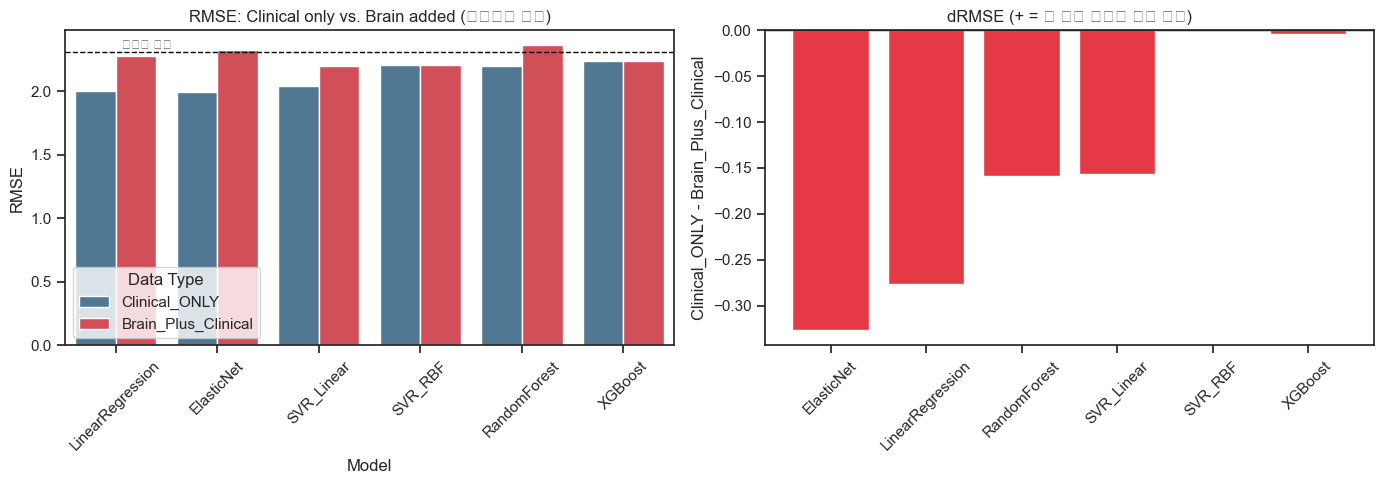

In [7]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[SVR_Linear / Clinical_ONLY] 고유 조합 12개, 최빈 43%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 7개, 최빈 84%
[RandomForest / Clinical_ONLY] 고유 조합 5개, 최빈 61%
[XGBoost / Clinical_ONLY] 고유 조합 4개, 최빈 86%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 3개, 최빈 64%
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 8개, 최빈 57%
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 8개, 최빈 45%   <-- 불안정
[RandomForest / Brain_Plus_Clinical] 고유 조합 7개, 최빈 34%   <-- 불안정
[XGBoost / Brain_Plus_Clinical] 고유 조합 3개, 최빈 66%


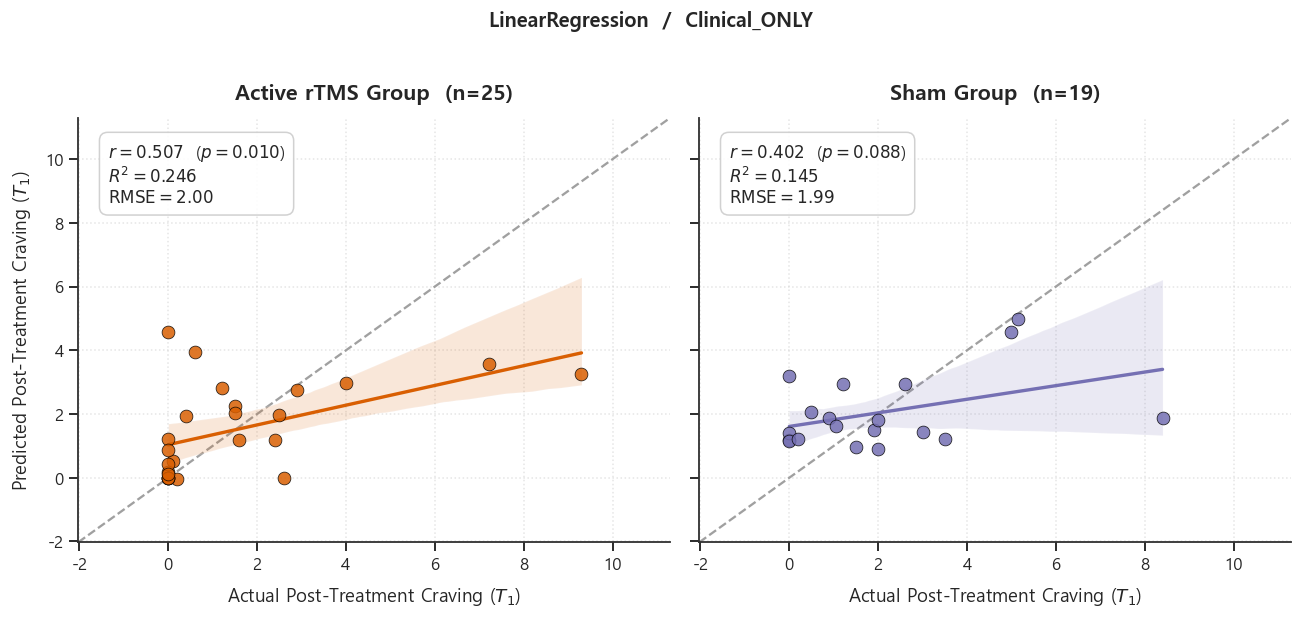

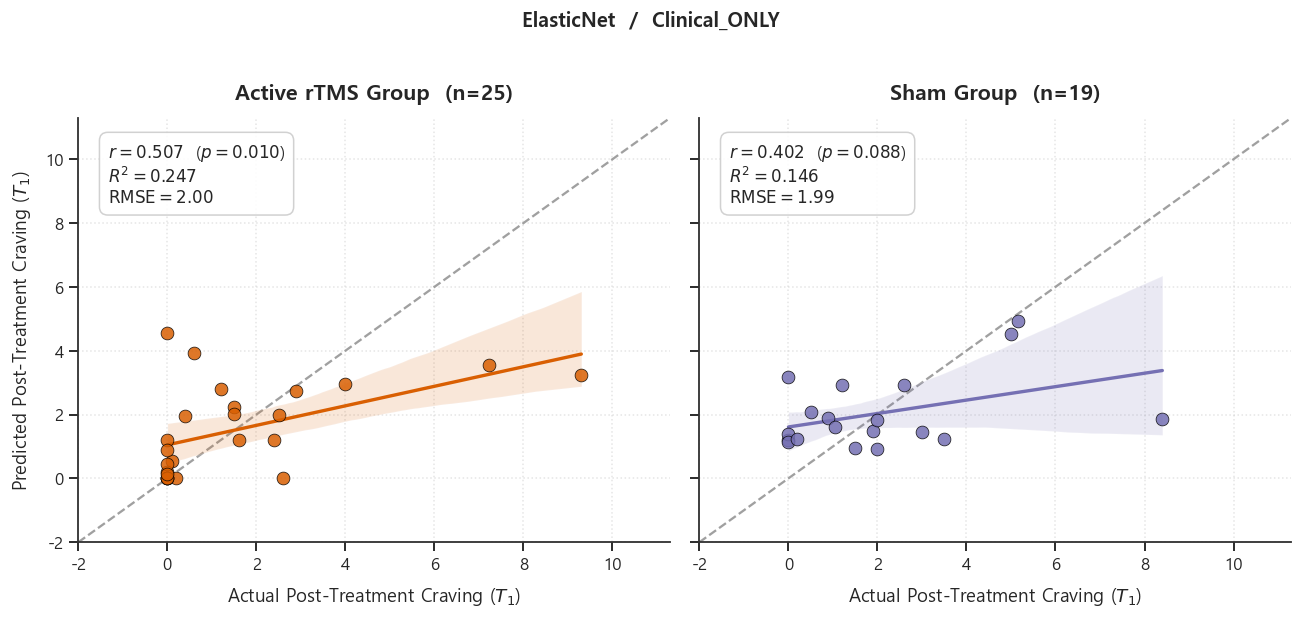

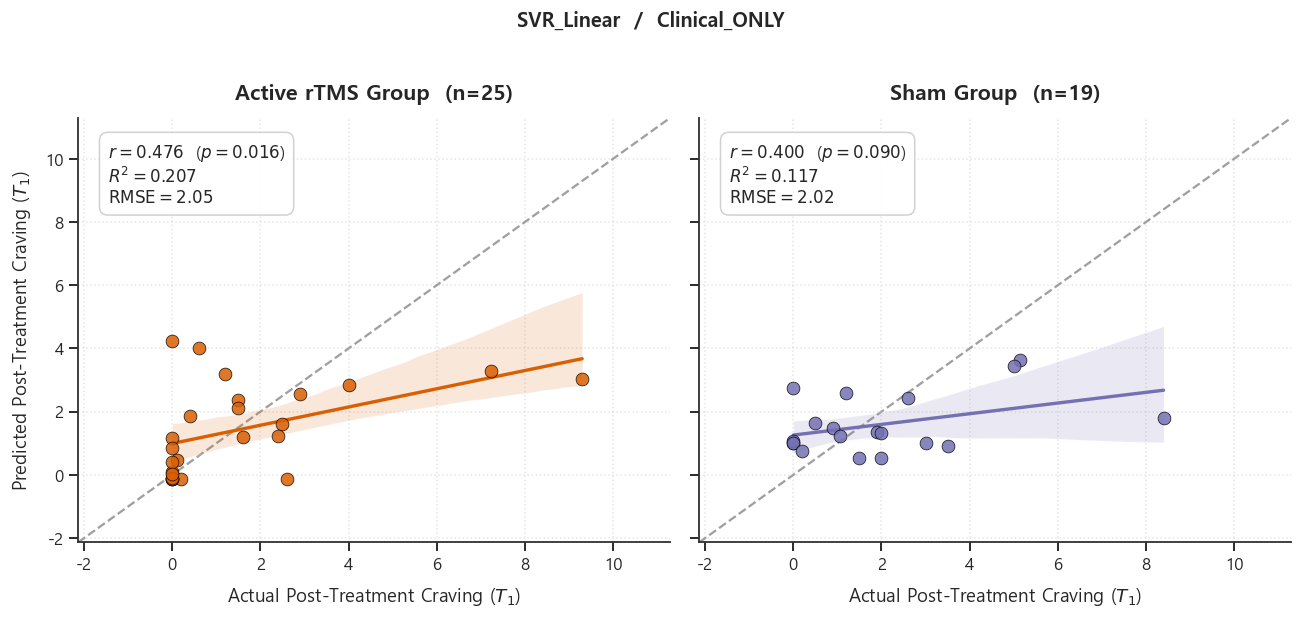

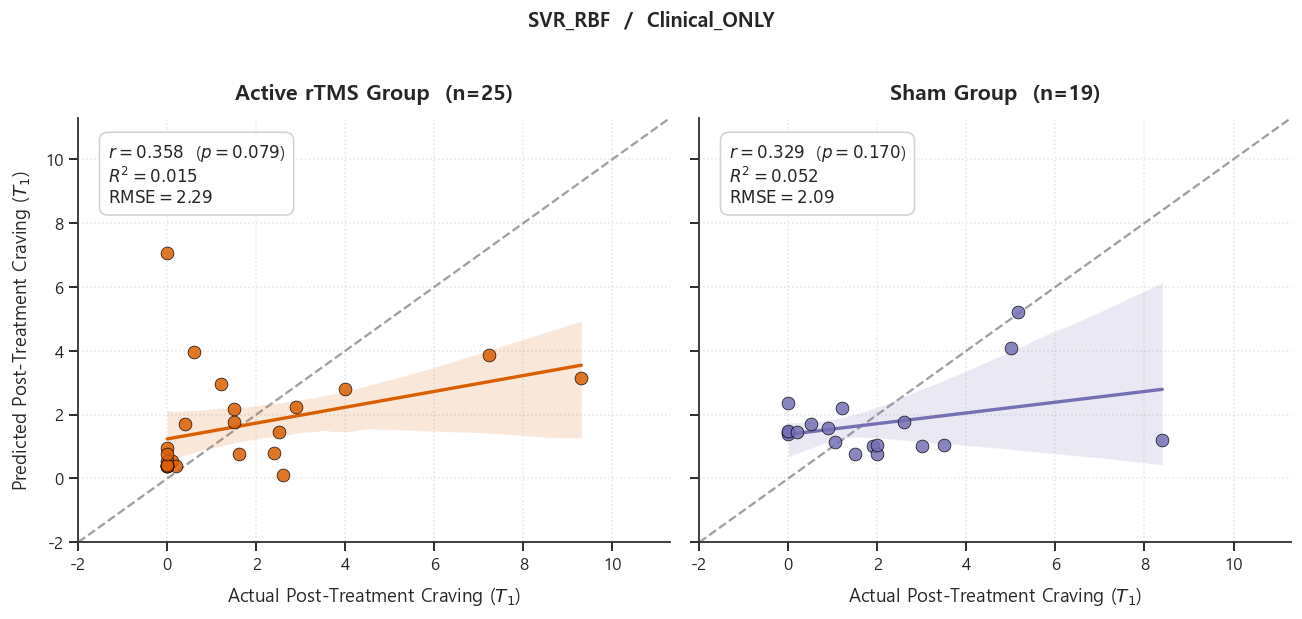

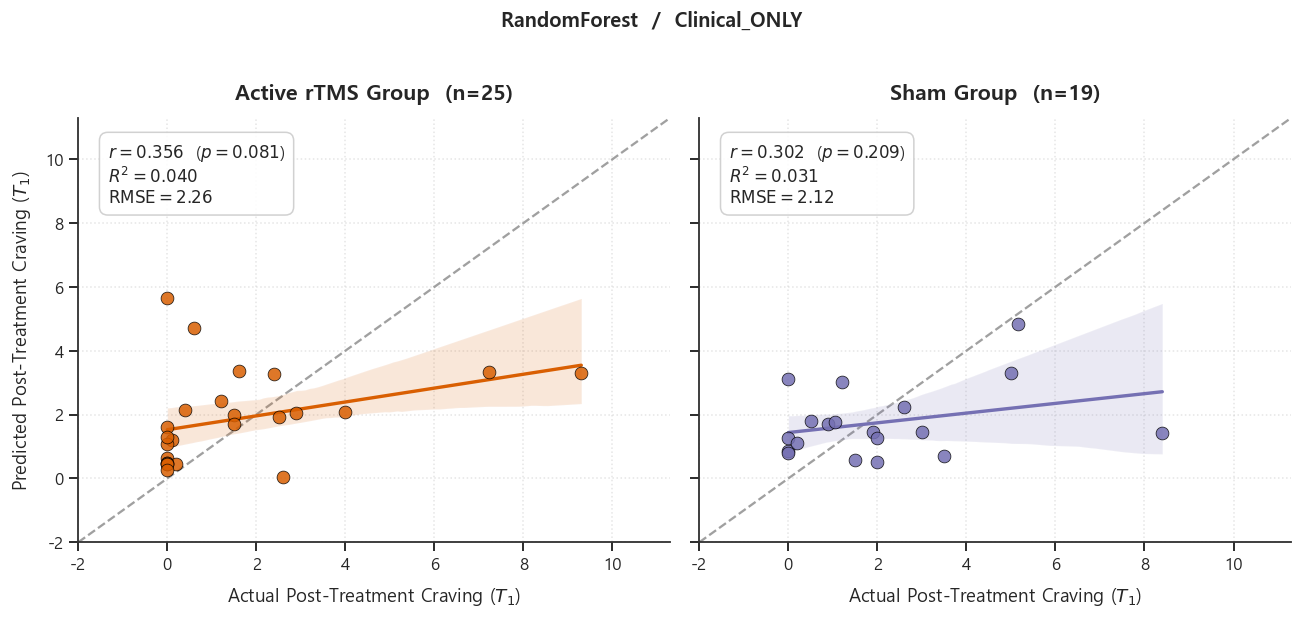

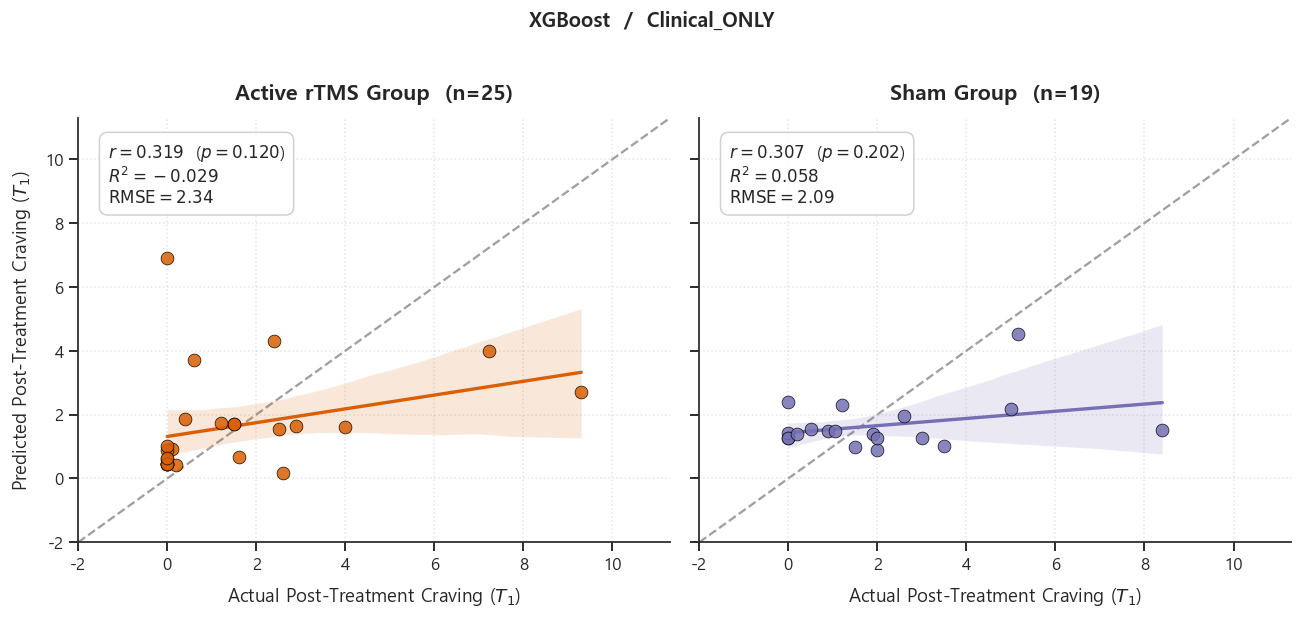

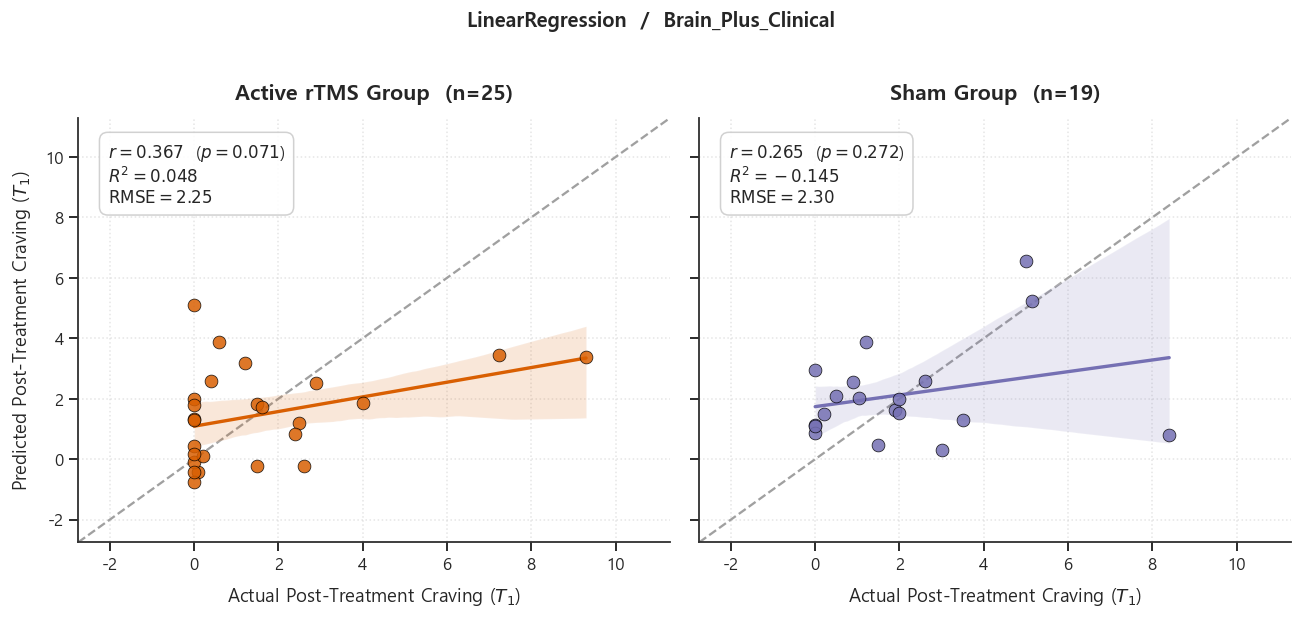

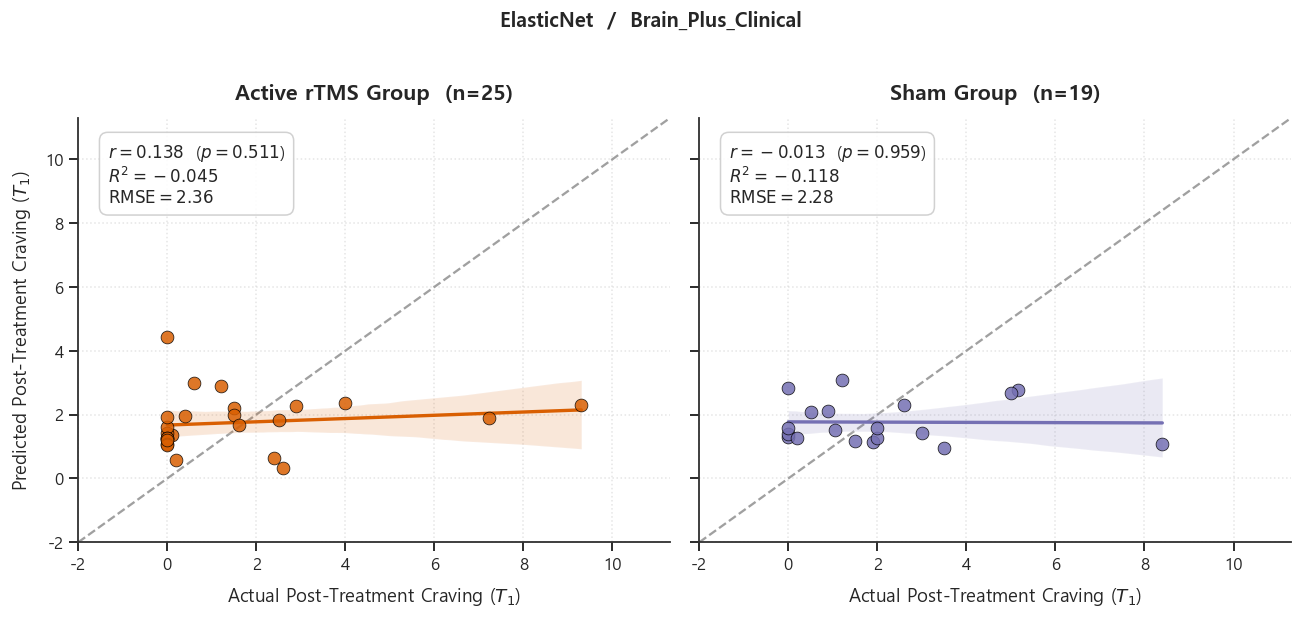

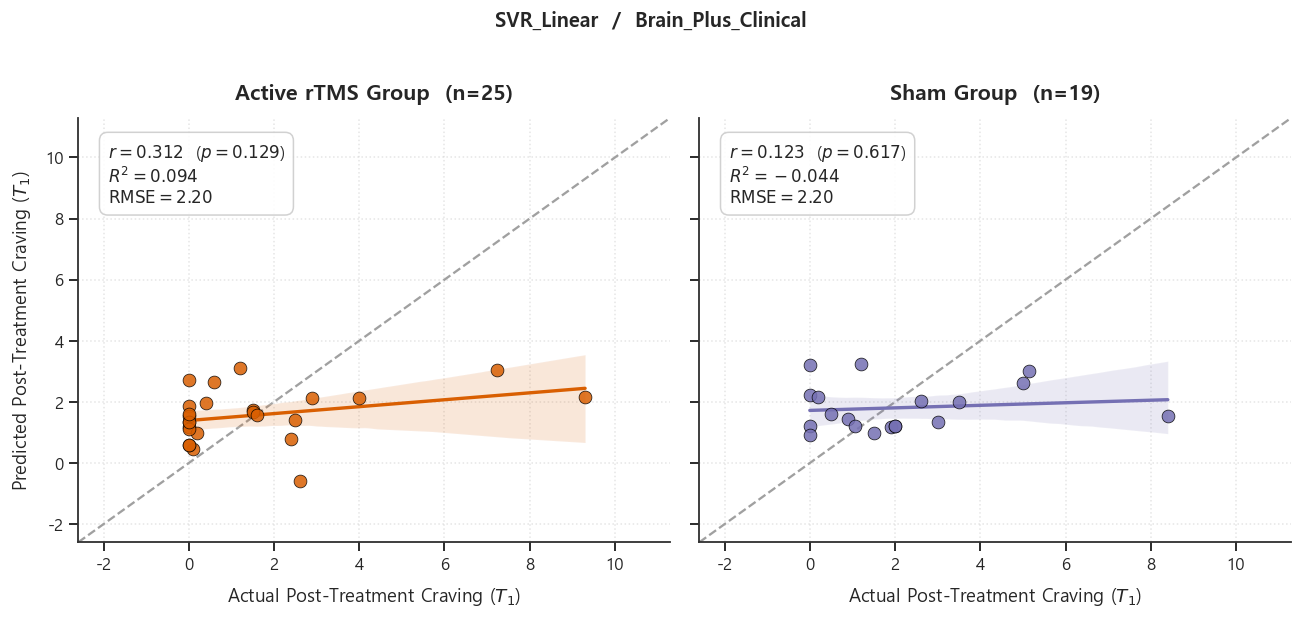

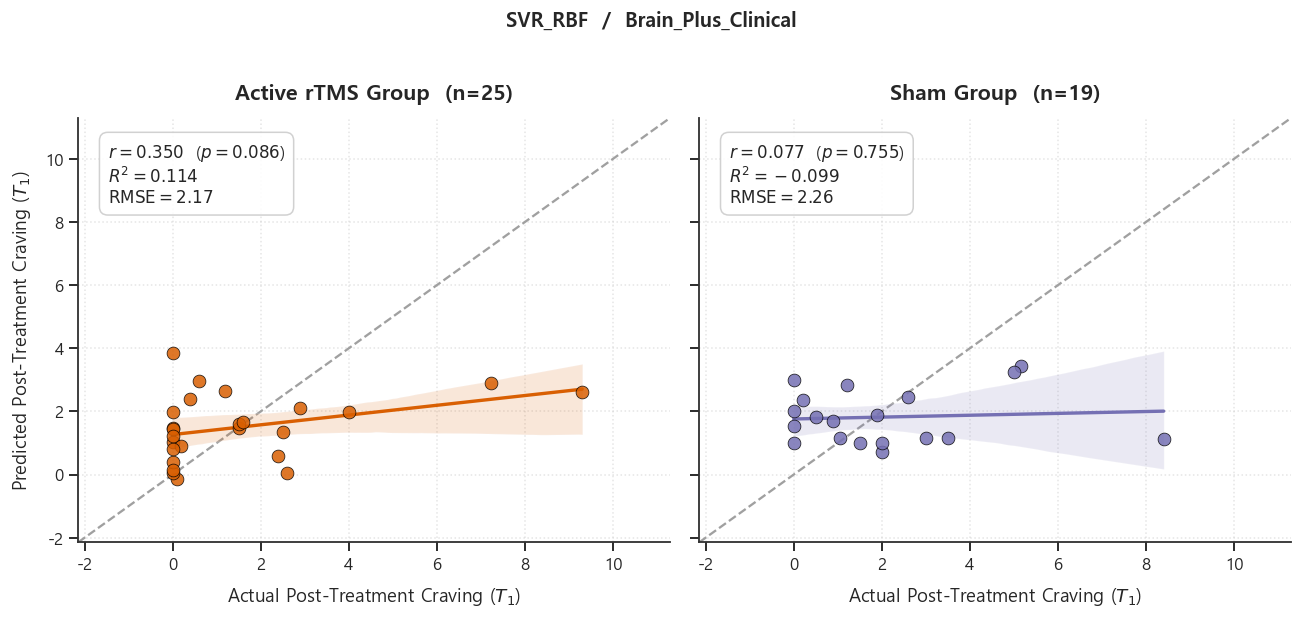

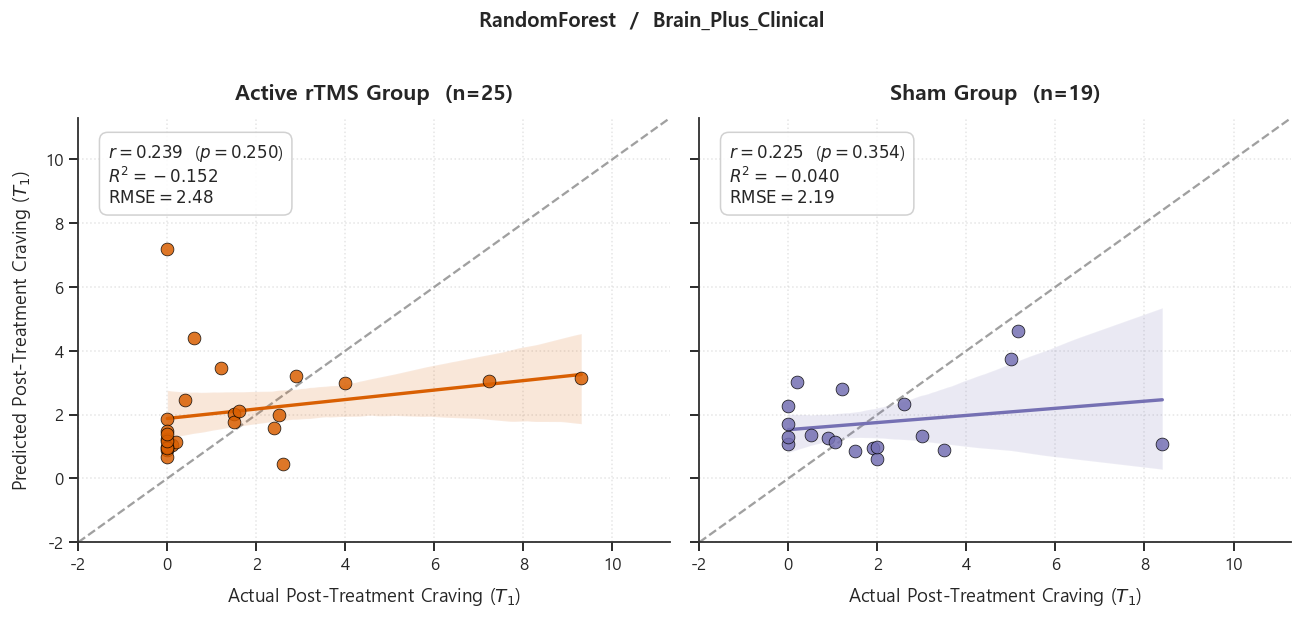

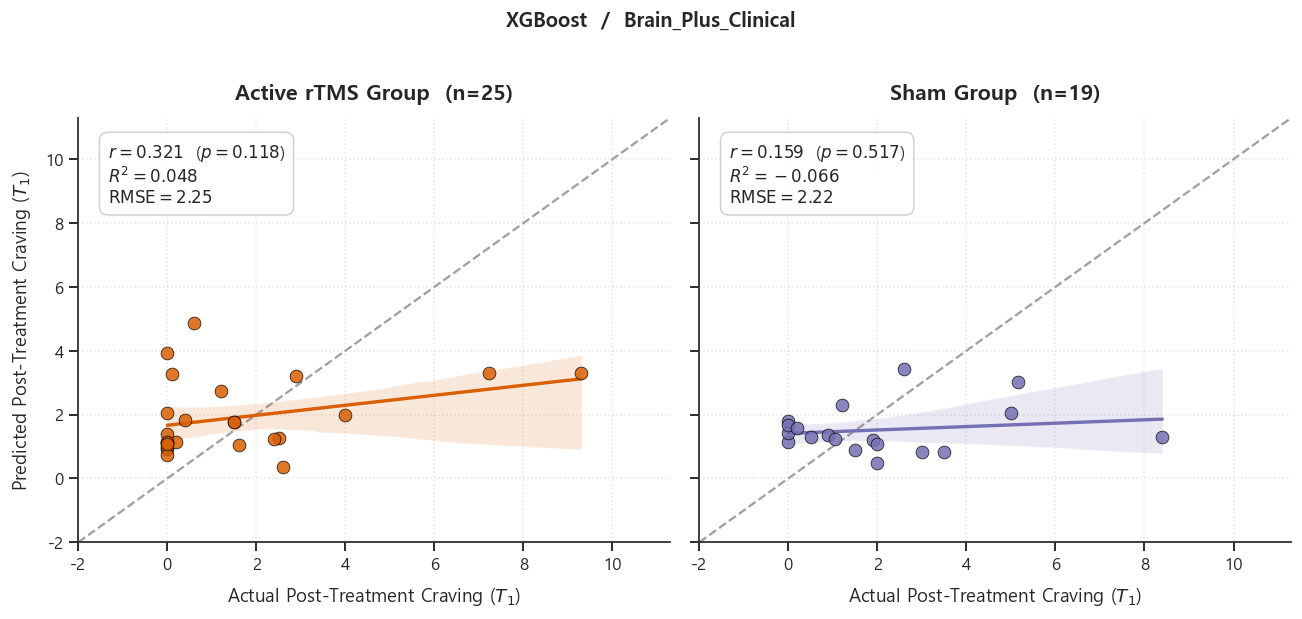

In [9]:
# ==========================================================
# 7. Active vs Sham — 12세트 전부
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups = ['Active rTMS', 'Sham']

for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)

    plot_df = pd.DataFrame({
        'True_Craving': y,
        'Pred_Craving': y_pred,
        'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=110)

    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 2
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 2

    for i, grp in enumerate(groups):
        ax = axes[i]
        sub_df = plot_df[plot_df['Group'] == grp]
        color = palette[grp]

        r, pval = pearsonr(sub_df['True_Craving'], sub_df['Pred_Craving'])
        r2 = r2_score(sub_df['True_Craving'], sub_df['Pred_Craving'])
        rmse = np.sqrt(np.mean((sub_df['True_Craving'] - sub_df['Pred_Craving']) ** 2))

        ax.plot([min_val, max_val], [min_val, max_val],
                color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)
        sns.scatterplot(data=sub_df, x='True_Craving', y='Pred_Craving',
                        color=color, s=70, alpha=0.85, edgecolor='black',
                        linewidth=0.5, ax=ax, zorder=3)
        sns.regplot(data=sub_df, x='True_Craving', y='Pred_Craving',
                    ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95)

        ax.set_title(f'{grp} Group  (n={len(sub_df)})', fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
        if i == 0:
            ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)

        stats_text = (f"$r = {r:.3f}$  ($p = {pval:.3f}$)\n"
                      f"$R^2 = {r2:.3f}$\n"
                      f"$\\mathrm{{RMSE}} = {rmse:.2f}$")
        ax.text(0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.5)

    fig.suptitle(f'{name}  /  {dt}', fontsize=13, fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [10]:
# ==========================================================
# 8. 군간 아티팩트 점검 — vas 분산 / 상관 구조가 다른가
# ==========================================================
from scipy.stats import levene

g = df['treatment_group'].values
vt0, vt1 = df['vas_t0'].values, df['vas_t1'].values

rows = []
for grp, code_ in [('Active', 2), ('Sham', 1)]:
    m = g == code_
    r_raw, p_raw = pearsonr(vt0[m], vt1[m])
    rows.append({
        'group': grp, 'n': m.sum(),
        'vas_t0_mean': vt0[m].mean(), 'vas_t0_SD': vt0[m].std(ddof=1),
        'vas_t1_mean': vt1[m].mean(), 'vas_t1_SD': vt1[m].std(ddof=1),
        'r(t0,t1)': r_raw, 'p': p_raw
    })
print(pd.DataFrame(rows).round(3).to_string(index=False))

for v, nm in [(vt0, 'vas_t0'), (vt1, 'vas_t1')]:
    W, p = levene(v[g == 2], v[g == 1])
    print(f"Levene {nm}: W={W:.3f}, p={p:.3f}")

 group  n  vas_t0_mean  vas_t0_SD  vas_t1_mean  vas_t1_SD  r(t0,t1)     p
Active 25        3.803      3.582        1.521      2.356     0.633 0.001
  Sham 19        2.628      2.903        2.047      2.210     0.491 0.033
Levene vas_t0: W=2.323, p=0.135
Levene vas_t1: W=0.019, p=0.890
